# Evaluating confidence predictor

Here, we evaluate our three confidence prediction methods and assess how well they match to poorly predicted data points.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as rt
import pandas as pd
import seaborn as sns
import torch
from Bio.SeqUtils import IUPACData
from scipy import stats

from tcr_antigen_prediction.models import TCRContactMapPredictor

In [2]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr_1as = fh['cdr_1a'][:]
    cdr_2as = fh['cdr_2a'][:]
    cdr_3as = fh['cdr_3a'][:]
    cdr_1bs = fh['cdr_1b'][:]
    cdr_2bs = fh['cdr_2b'][:]
    cdr_3bs = fh['cdr_3b'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo_sequence'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

results = pd.DataFrame(
    {
        'cdr_1a': list(cdr_1as),
        'cdr_2a': list(cdr_2as),
        'cdr_3a': list(cdr_3as),
        'cdr_1b': list(cdr_1bs),
        'cdr_2b': list(cdr_2bs),
        'cdr_3b': list(cdr_3bs),
        'peptide': list(peptides),
        'mhc': list(mhcs),
        'fold': folds,
        'label': labels,
    }
)

In [3]:
indices = np.arange(len(labels))

In [4]:
rng = np.random.default_rng(123)
sample_indices = rng.choice(indices, int(len(indices) * 0.1))

In [5]:
tcr_pmhcs = np.concatenate([cdr_1as, cdr_2as, cdr_3as, cdr_1bs, cdr_2bs, cdr_3bs, peptides, mhcs], axis=1)
tcr_pmhcs_flat = tcr_pmhcs.reshape(tcr_pmhcs.shape[0], -1)

In [6]:
fold_results = []
NUM_CONFIDENCE_PREDICTIONS = 5

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    fold_predictions = results.loc[sample_indices].copy()
    fold_predictions['holdout_fold'] = fold_num

    print('Loading model')
    model = TCRContactMapPredictor(drop_out_rate=0.6)
    model.load_state_dict(
        torch.load(
            f'models/TCRContactMapPredictor/model_{fold_num}.pt',
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    predictions = model(
        torch.tensor(cdr_1as[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_2as[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_3as[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_1bs[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_2bs[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_3bs[sample_indices], dtype=torch.float32),
        torch.tensor(peptides[sample_indices], dtype=torch.float32),
        torch.tensor(mhcs[sample_indices], dtype=torch.float32),
    )

    fold_predictions['prediction'] = predictions.squeeze(-1).detach().cpu().numpy()

    print('Making confidence prediction')
    model.train()
    for i in range(NUM_CONFIDENCE_PREDICTIONS):
        print(i + 1, 'of', NUM_CONFIDENCE_PREDICTIONS)
        confidence_prediction = model(
            torch.tensor(cdr_1as[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_2as[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_3as[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_1bs[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_2bs[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_3bs[sample_indices], dtype=torch.float32),
            torch.tensor(peptides[sample_indices], dtype=torch.float32),
            torch.tensor(mhcs[sample_indices], dtype=torch.float32),
        )

        fold_predictions[f'confidence_prediction_{i}'] = confidence_prediction.squeeze(-1).detach().cpu().numpy()

    print('Making confidence prediction from regressor')
    sess = rt.InferenceSession(f'models/ConfidencePredictor/model_{fold_num}.onnx')
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    confidence, *_ = sess.run(None, {'X': tcr_pmhcs_flat[sample_indices].astype(np.float32)})
    fold_predictions['confidence_distance_regressor'] = confidence.squeeze(-1)

    fold_results.append(fold_predictions)

    print('Finished fold')

results = pd.concat(fold_results).reset_index(drop=True)

Fold: 1
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-02-03 17:19:57.336877429 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2959275, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:19:57.344787566 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2959276, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:19:57.352343991 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2959277, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:19:57.356567131 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2959278, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold
Fold: 2
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-02-03 17:20:30.675838381 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961243, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:20:30.680568862 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961244, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:20:30.684567522 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961245, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:20:30.691140385 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961246, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold
Fold: 3
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


...

Finished fold
Fold: 4
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-02-03 17:21:34.352655296 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961722, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:21:34.356577133 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961723, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:21:34.362911628 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961724, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:21:34.367978229 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961725, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold
Fold: 5
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-02-03 17:22:06.492396862 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961964, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:22:06.496585880 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961965, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:22:06.502661170 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961966, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-02-03 17:22:06.507721328 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2961967, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold


In [7]:
THRESHOLD = 0.5
results['prediction_binary'] = (results['prediction'] > THRESHOLD).apply(int)

In [8]:
results['residual_abs'] = np.abs(results['label'] - results['prediction'])
results['residual_squared'] = (results['label'] - results['prediction']) ** 2

In [9]:
results['correct'] = results['prediction_binary'] == results['label']

In [10]:
results['in_training_data'] = results['fold'] != results['holdout_fold']

<Axes: xlabel='correct', ylabel='percent'>

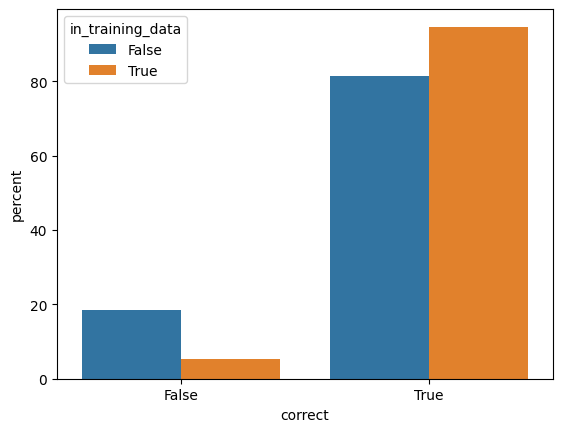

In [11]:
sns.barplot(
    results.groupby('in_training_data')['correct']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(),
    x='correct',
    y='percent',
    hue='in_training_data',
)

In [12]:
amino_acid_olcs = np.array(sorted(IUPACData.protein_letters_3to1.values()))
amino_acid_olcs

array(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P',
       'Q', 'R', 'S', 'T', 'V', 'W', 'Y'], dtype='<U1')

In [13]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [14]:
peptides_aa = np.array(
    [
        ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
        for peptide in peptides
    ]
)

In [15]:
results['peptide_sequence'] = results['peptide'].map(
    lambda peptide: ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
)

In [16]:
# TODO think about how to handle peptides that have been cropped...


def get_minimum_peptide_distance(peptide_sequence: str, fold: int) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_peptides = peptides_aa[folds != fold]
    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [17]:
peptide_folds = results[['peptide_sequence', 'fold']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(row.peptide_sequence, row.fold),
    axis=1,
)

In [18]:
results = results.merge(peptide_folds, how='left', on=['peptide_sequence', 'fold'])

## Confidence from Logits

In [19]:
results['confidence_logits'] = np.max(np.stack([1 - results['prediction'], results['prediction']], axis=1), axis=1)

<Axes: ylabel='Frequency'>

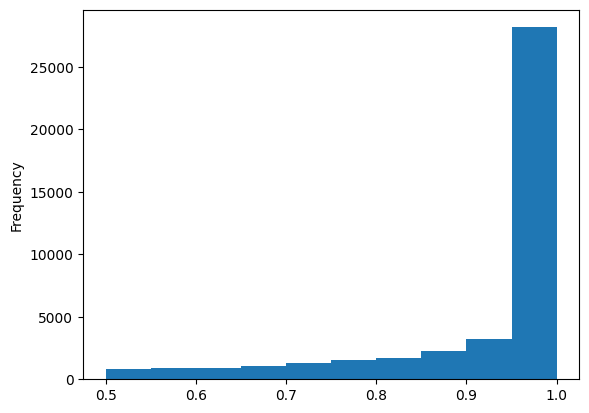

In [20]:
results['confidence_logits'].plot.hist()

<Axes: xlabel='correct', ylabel='confidence_logits'>

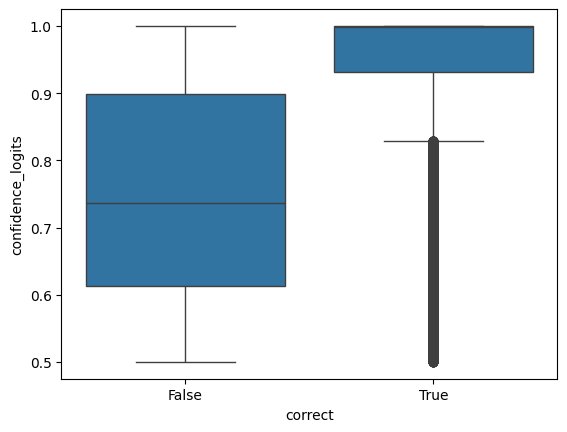

In [21]:
sns.boxplot(results, y='confidence_logits', x='correct')

<Axes: xlabel='in_training_data', ylabel='confidence_logits'>

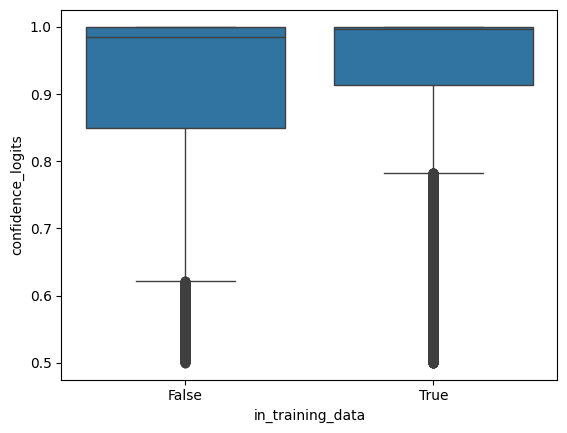

In [22]:
sns.boxplot(results, y='confidence_logits', x='in_training_data')

In [23]:
results['confidence_logits_scaled'] = 2 * results['confidence_logits'] - 1

<Axes: ylabel='Frequency'>

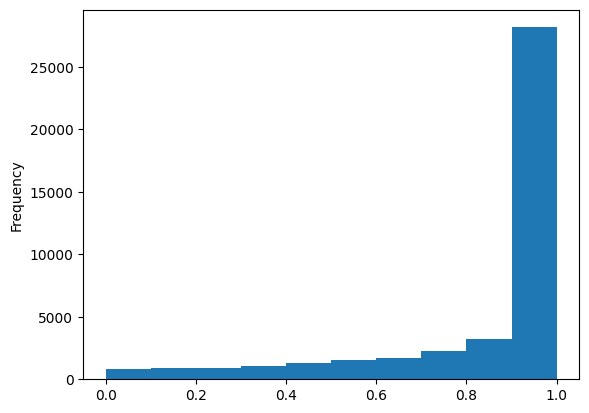

In [24]:
results['confidence_logits_scaled'].plot.hist()

<Axes: xlabel='correct', ylabel='confidence_logits_scaled'>

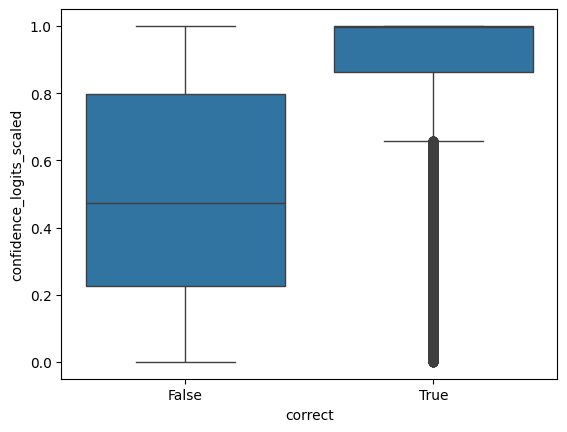

In [25]:
sns.boxplot(results, y='confidence_logits_scaled', x='correct')

<Axes: xlabel='in_training_data', ylabel='confidence_logits_scaled'>

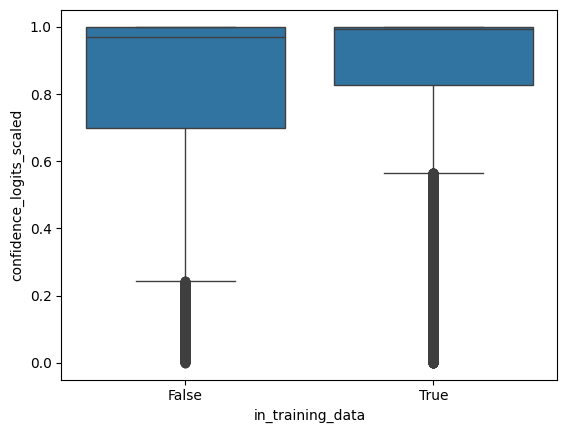

In [26]:
sns.boxplot(results, y='confidence_logits_scaled', x='in_training_data')

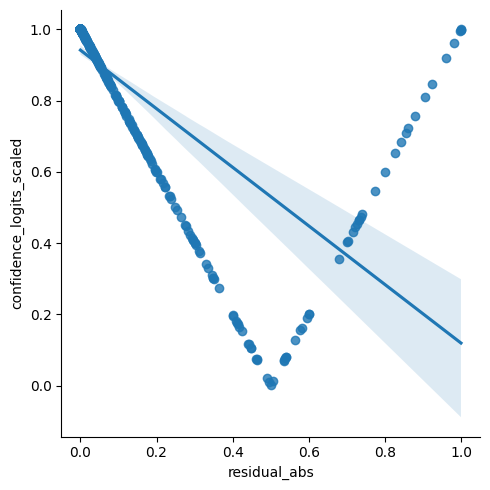

In [27]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_logits_scaled')

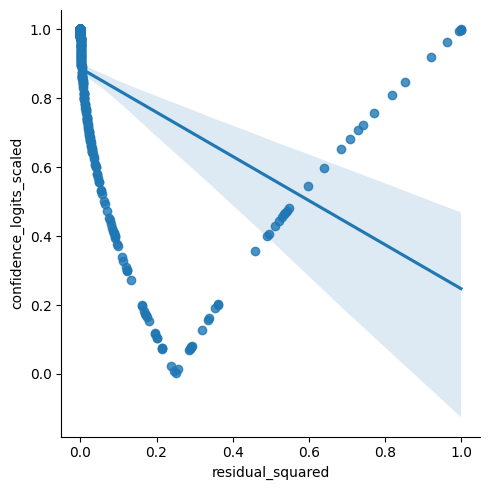

In [28]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_logits_scaled')

## Confidence from Monte-Carlo dropout

In [29]:
prediction_std = results.filter(regex=r'confidence_prediction_\d').apply(np.std, axis=1)

<Axes: ylabel='Frequency'>

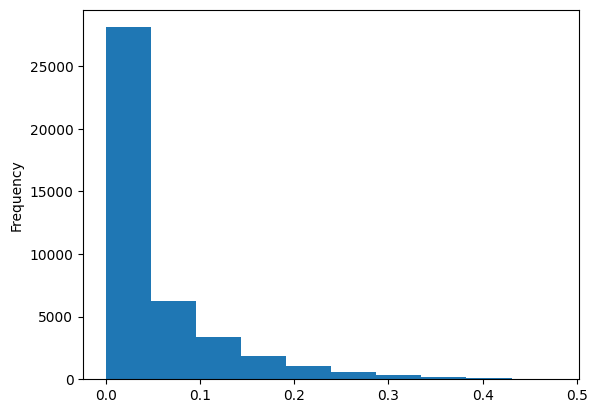

In [30]:
prediction_std.plot.hist()

In [31]:
confidence_prediction = 1 - prediction_std / prediction_std.max()

<Axes: ylabel='Frequency'>

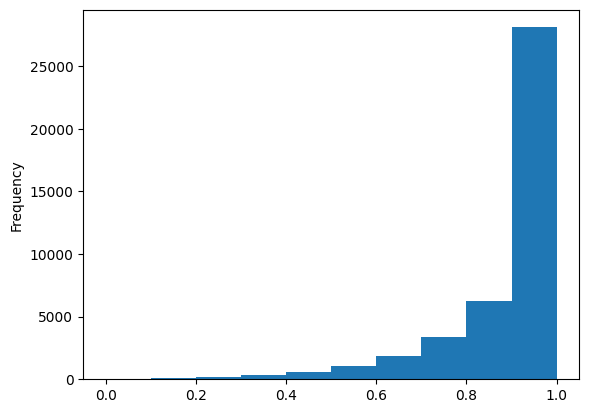

In [32]:
confidence_prediction.plot.hist()

In [33]:
results['confidence_prediction'] = confidence_prediction

<Axes: xlabel='in_training_data', ylabel='confidence_prediction'>

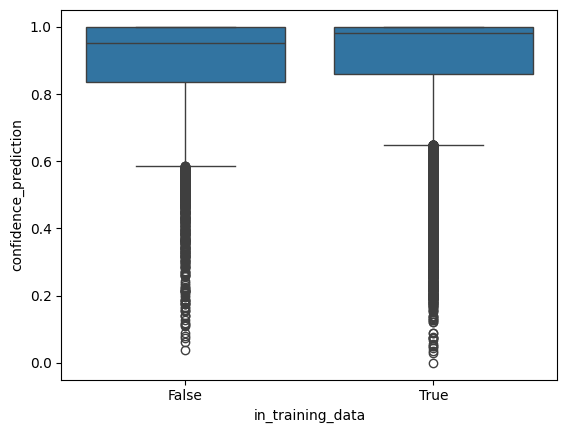

In [34]:
sns.boxplot(results, x='in_training_data', y='confidence_prediction')

<Axes: xlabel='correct', ylabel='confidence_prediction'>

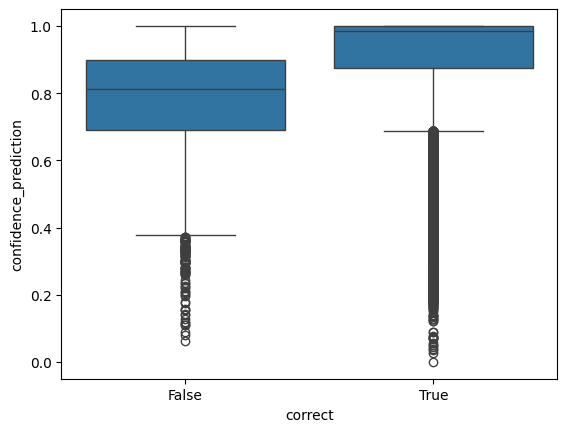

In [35]:
sns.boxplot(results, x='correct', y='confidence_prediction')

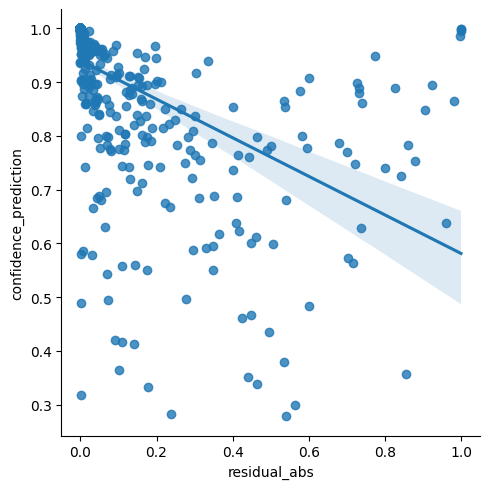

In [36]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_prediction')

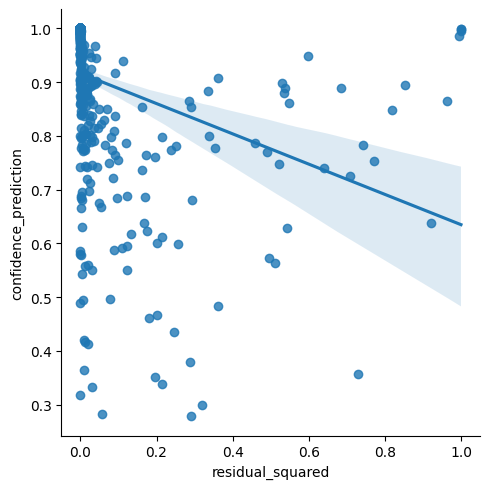

In [37]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_prediction')

## Distance Based Regressor

<Axes: xlabel='in_training_data', ylabel='confidence_distance_regressor'>

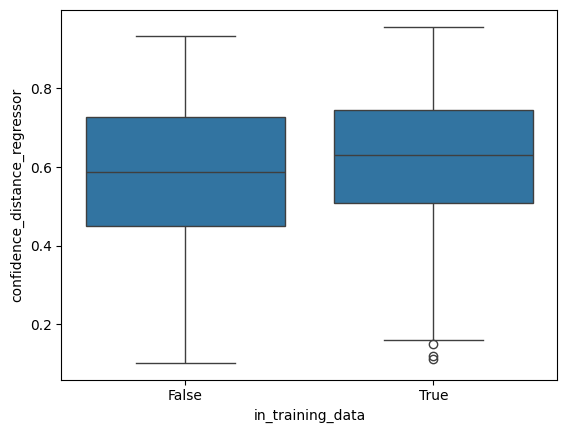

In [38]:
sns.boxplot(results, x='in_training_data', y='confidence_distance_regressor')

<Axes: xlabel='correct', ylabel='confidence_distance_regressor'>

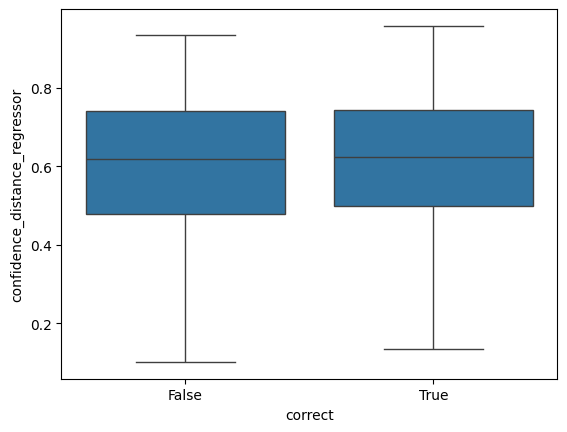

In [39]:
sns.boxplot(results, x='correct', y='confidence_distance_regressor')

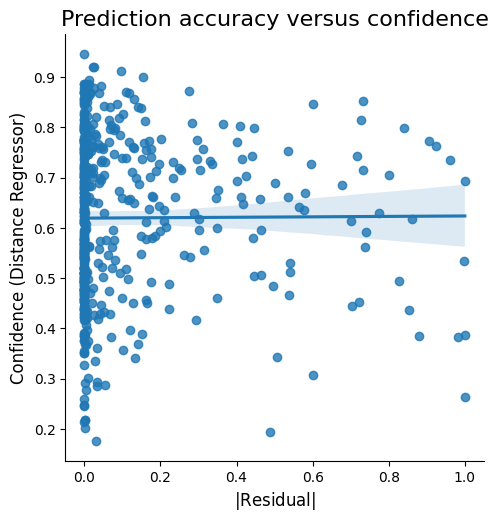

In [40]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_distance_regressor')

plt.title('Prediction accuracy versus confidence', fontsize=16)
plt.xlabel(r'$|\text{Residual}|$', fontsize=12)
plt.ylabel('Confidence (Distance Regressor)', fontsize=12)

plt.show()

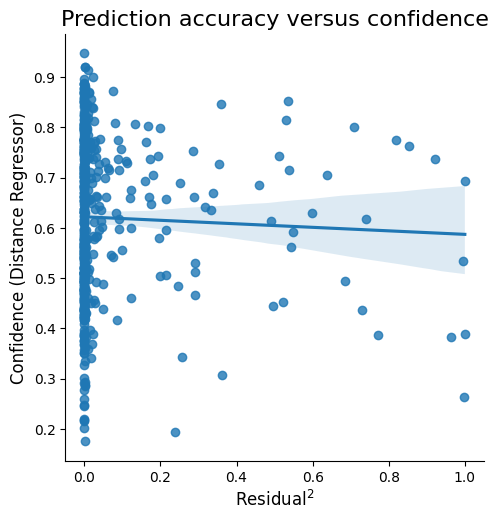

In [41]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_distance_regressor')

plt.title('Prediction accuracy versus confidence', fontsize=16)
plt.xlabel(r'$\text{Residual}^2$', fontsize=12)
plt.ylabel('Confidence (Distance Regressor)', fontsize=12)

plt.show()

## Comparison between approaches

### Correlation

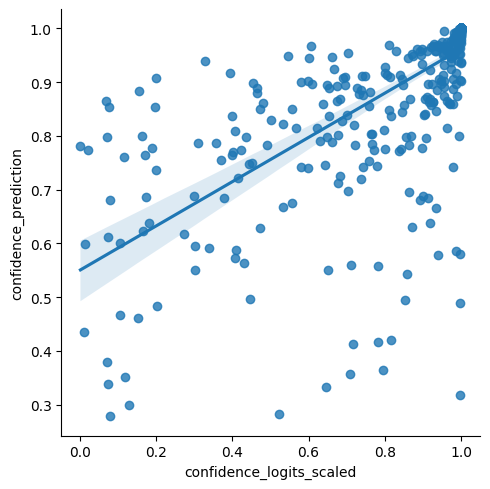

In [42]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_logits_scaled', y='confidence_prediction')

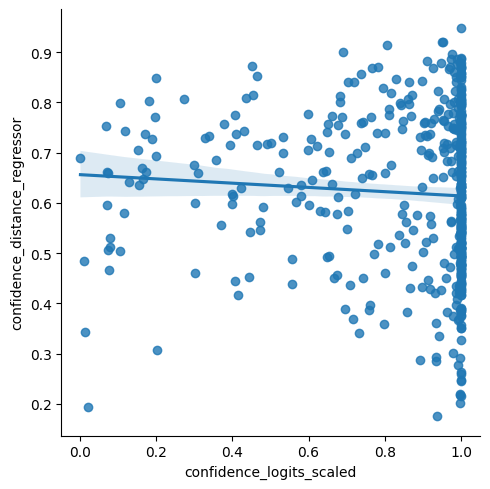

In [43]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_logits_scaled', y='confidence_distance_regressor')

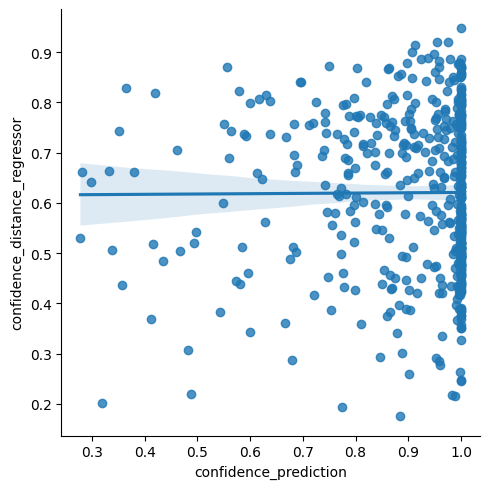

In [44]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_prediction', y='confidence_distance_regressor')

### Comparison

In [45]:
results_long = results.melt(
    id_vars=[
        'cdr_1a',
        'cdr_2a',
        'cdr_3a',
        'cdr_1b',
        'cdr_2b',
        'cdr_3b',
        'peptide',
        'mhc',
        'fold',
        'label',
        'holdout_fold',
        'prediction',
        'prediction_binary',
        'in_training_data',
        'correct',
        'min_peptide_distance',
    ],
    value_vars=['confidence_logits', 'confidence_prediction', 'confidence_distance_regressor'],
    var_name='method',
    value_name='confidence',
)

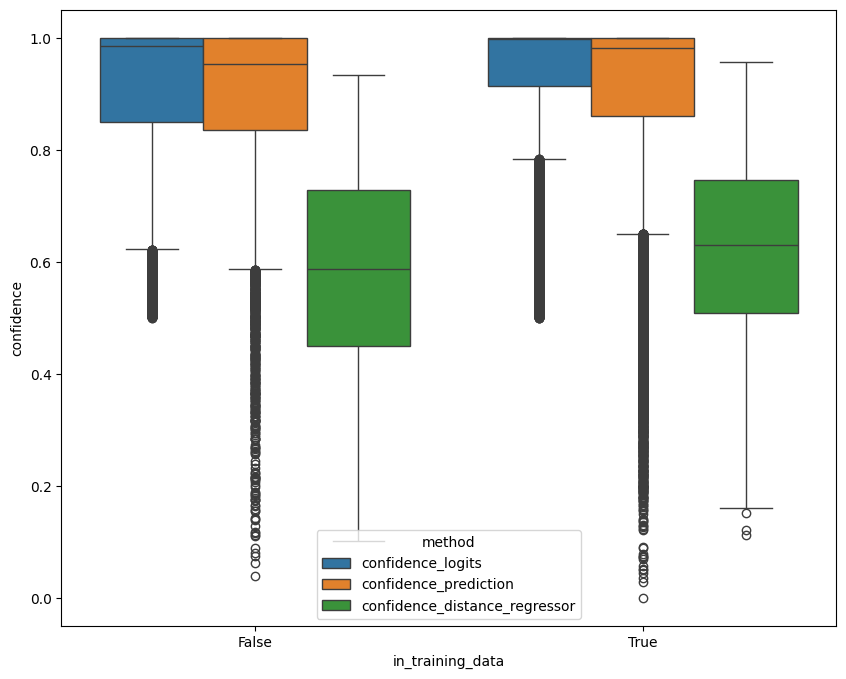

In [46]:
plt.figure(figsize=(10, 8))
sns.boxplot(results_long, x='in_training_data', y='confidence', hue='method')
plt.show()

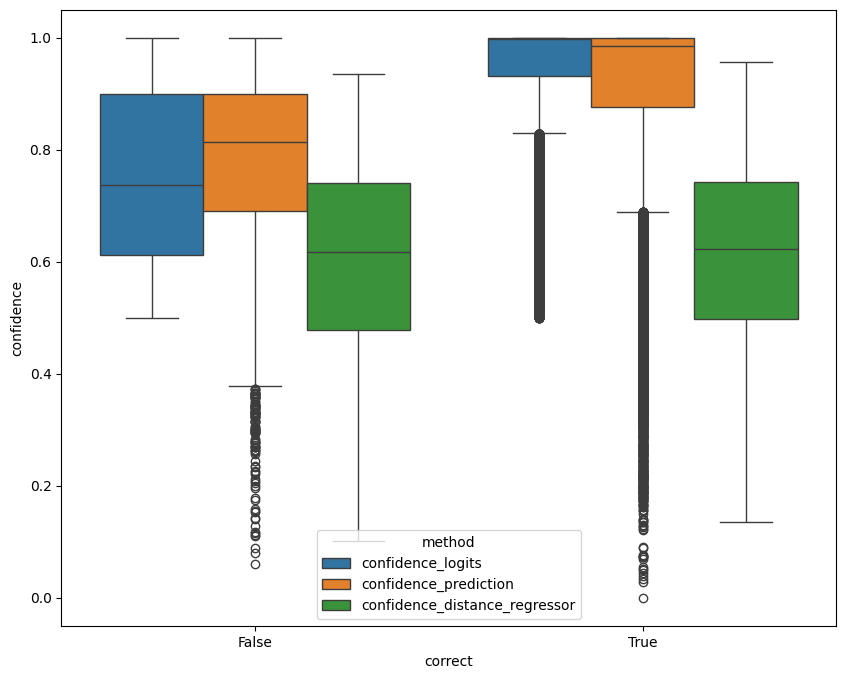

In [47]:
plt.figure(figsize=(10, 8))
sns.boxplot(results_long, x='correct', y='confidence', hue='method')
plt.show()

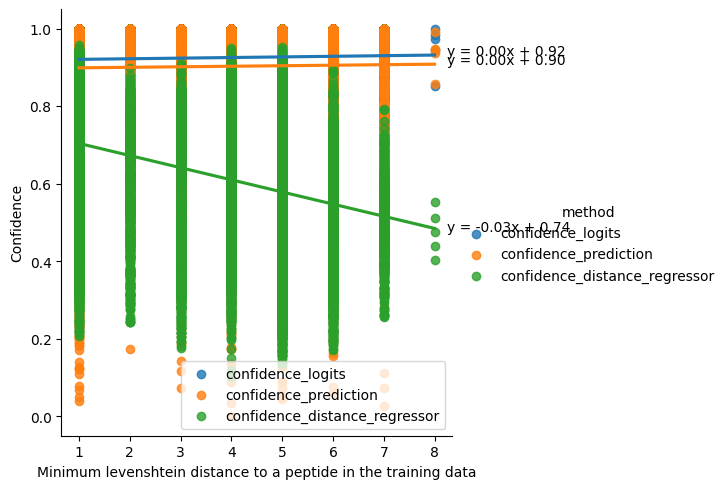

In [48]:
sns.lmplot(results_long, x='min_peptide_distance', y='confidence', hue='method')

for method in results_long['method'].unique():
    subset = results_long[results_long['method'] == method].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['confidence'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'
    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('Confidence')
plt.legend(loc='lower right')

plt.show()

In [49]:
lines = (
    results_long.dropna()
    .groupby(['method', 'fold'])
    .apply(
        lambda group: stats.linregress(group['min_peptide_distance'], group['confidence']),
        include_groups=False,
    )
)

lines.name = 'line'
lines = lines.reset_index()

lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = lines['line'].apply(pd.Series)

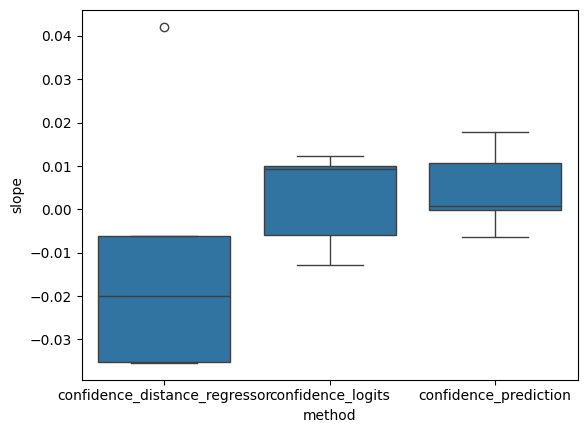

,mean,median,std
method,,,
confidence_distance_regressor,-0.010944,-0.019975,0.032033
confidence_logits,0.002621,0.009338,0.011236
confidence_prediction,0.004538,0.000689,0.009651


In [50]:
sns.boxplot(lines, x='method', y='slope')
plt.show()

lines.groupby('method')['slope'].agg(['mean', 'median', 'std'])

In [51]:
stats.kruskal(*[val for _, val in list(lines.groupby('method')['slope'])])

KruskalResult(statistic=2.5799999999999983, pvalue=0.27527078308975256)